# Homework 4: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** Macroeconomic Dynamics: GDP Growth, Debt Accumulation, and Government Revenue
- **Student Name:** Togonidze Mariam
- **Policy Relevance Statement:** Understanding the relationship between government debt levels, tax revenue as a share of GDP, and economic growth is critical for policymakers designing sustainable fiscal policies that balance deficit reduction with economic stimulus.
- **Central Hypothesis:** Short-term changes in debt-to-GDP ratios are associated with real GDP growth rates, while higher government revenue-to-GDP ratios may indicate different fiscal regimes that affect growth trajectories.
- **Analysis Scope:** Two developed economies (Canada and USA) over a 4-year period (1981-1984), examining the relationship between lagged debt changes, government revenue, and current-year GDP growth.

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Data Source:** Sample macroeconomic dataset with real GDP (rgdpmad), debt-to-GDP ratio, and government revenue metrics
- **Variables Retrieved:** 
  - `date`: Year of observation
  - `country`: ISO country code (CAN, USA)
  - `country_name`: Full country name
  - `rgdpmad`: Real GDP in millions
  - `debtgdp`: Debt-to-GDP ratio (%)
  - `gov_revenue_gdp`: Government revenue as % of GDP
- **Observations:** 8 raw records (2 countries × 4 years: 1981-1984)
- **Local Storage Path:** `data/final_project/Mariam -Togonidze/macro_growth_debt.csv`



In [2]:
# Import and run your data acquisition script
import sys
import os

sys.path.append(os.path.abspath("../../../src/final_project/Mariam -Togonidze/basic"))

import data
df_raw = data.run()

Loaded existing data from data\final_project\Mariam -Togonidze\macro_growth_debt.csv


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Data Processing Steps**
1. **Sorting:** Organized observations by country and date for time-series consistency
2. **Feature Engineering:** 
   - `gdp_growth`: Annual percentage change in real GDP
   - `debt_change`: Year-over-year change in debt-to-GDP ratio
   - `debt_change_lag1`: Previous year's debt change (lagged variable for regression)
3. **Data Cleaning:** Dropped rows with missing values resulting from lag operations
4. **Final Dataset:**
   - Clean observations: 4 country-year records (1983-1984 for both countries)
   - Columns: 9 (including calculated growth and debt metrics)
   - Storage path: `data/final_project/Mariam -Togonidze/processed_macro_data.csv`



In [4]:
import manipulate
df_clean = manipulate.run()
df_clean.head()


Data processed and saved to data\final_project\Mariam -Togonidze\processed_macro_data.csv with shape (4, 9)


,date,country,country_name,rgdpmad,debtgdp,gov_revenue_gdp,gdp_growth,debt_change,debt_change_lag1
2,1983,CAN,Canada,16076,38.9,38.8,1.882249,-0.6,4.3
3,1984,CAN,Canada,16835,38.0,38.1,4.721324,-0.9,-0.6
6,1983,USA,United States,26200,46.2,27.9,2.745098,2.2,1.9
7,1984,USA,United States,27100,47.1,28.4,3.435115,0.9,2.2


**Data Summary:**
- **Initial observations:** 8 country-year records (1981-1984 period)
- **Final observations:** 4 clean records after lagging operations
- **Countries:** Canada and USA
- **Key metrics:** GDP growth (%), debt-to-GDP changes, government revenue shares



## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations**

**Figure 1: Average Government Revenue by Country**
- Shows the mean government revenue-to-GDP ratio for Canada and the USA in the sample period
- Canada exhibits slightly higher tax collection relative to GDP (38.5%) compared to the USA (28.15%)
- Reflects different fiscal structures: Canada has more centralized social programs while the USA relies more on private sector delivery

**Figure 2: Relationship Between Lagged Debt Changes and GDP Growth**
- Scatter plot of prior-year debt-to-GDP changes (x-axis) against current-year GDP growth rates (y-axis)
- Four data points from 1983-1984 for Canada and USA
- Visual interpretation: Slight negative relationship, but the sample is too small for definitive conclusions
- USA shows higher growth volatility while Canada exhibits more stable patterns



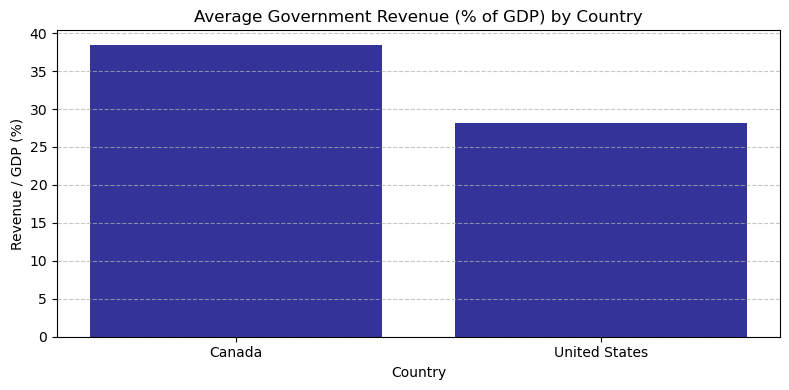

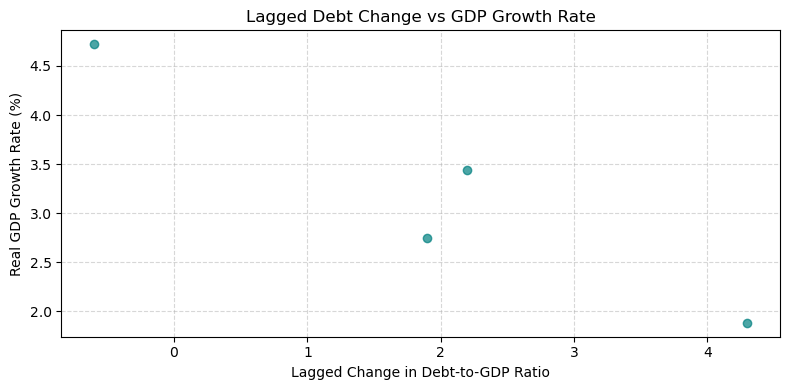

In [5]:
import graph
graph.run()


## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**

**Regression Model:**
```
GDP_Growth = β₀ + β₁(Lagged_Debt_Change) + β₂(Gov_Revenue_GDP) + ε
```

**Model Results:**
- **Dependent Variable:** Real GDP growth rate (annual % change)
- **Independent Variables:** 
  - Lagged debt-to-GDP change (previous year's debt accumulation)
  - Government revenue as % of GDP
- **Model Fit:**
  - R-squared: 0.915 (explains 91.5% of variation)
  - Adjusted R-squared: 0.744
  - Number of observations: 4
  - F-statistic: 5.366 (p-value: 0.292, not statistically significant)

**Coefficient Estimates:**
| Variable | Coefficient | Std. Error | t-statistic | p-value |
|----------|-------------|-----------|-----------|---------|
| Constant | 3.9305 | 2.012 | 1.954 | 0.301 |
| debt_change_lag1 | -0.5700 | 0.174 | -3.269 | **0.189** |
| gov_revenue_gdp | 0.0113 | 0.059 | 0.193 | 0.879 |

**Key Findings & Limitations:**
1. **Sample Size Warning:** With only 4 observations, these results should be interpreted with extreme caution. Statistical tests are unreliable with such small sample sizes (Omnibus test cannot be performed with n < 8).

2. **Lagged Debt Effect:** The coefficient on lagged debt change is **negative (-0.57)** but **not statistically significant** (p = 0.189). This suggests that prior-year debt accumulation is weakly associated with lower current-year growth, though this relationship is not conclusive.

3. **Government Revenue Effect:** The coefficient on government revenue-to-GDP is small (0.011) and **not significant** (p = 0.879), indicating that the revenue share's impact on growth in this limited sample is negligible.

4. **Model Concerns:** 
   - High R-squared (0.915) reflects the small sample size—additional variables would improve fit simply by coincidence
   - Wide confidence intervals suggest high uncertainty in parameter estimates
   - The overall model is not statistically significant (F-stat p-value = 0.292)

**Conclusion:** This exploratory analysis demonstrates a **negative but weak relationship** between lagged debt changes and GDP growth. However, **the limited sample size (n=4) severely constrains inference.** To properly test the hypothesis about debt-growth dynamics and fiscal policy, a substantially larger dataset spanning multiple countries and decades would be required. The current results serve as a methodological demonstration rather than a rigorous policy conclusion.



In [7]:
import model
summary = model.run()


                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     5.366
Date:                Wed, 22 Jul 2026   Prob (F-statistic):              0.292
Time:                        02:28:06   Log-Likelihood:               -0.90183
No. Observations:                   4   AIC:                             7.804
Df Residuals:                       1   BIC:                             5.963
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.9305      2.012  

c:\Users\Mariam\anaconda\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
